In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 18.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import rdkit
import torch
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
import re

# tokenizer.py

In [ ]:
# tokenizer.py

class Tokenizer:
    def __init__(self):
        self.vocab = [
              '#','%','(',')','+','-','.',
              '0','1','2','3','4','5','6','7','8','9','=',
              'B','Br','C','Cl','F','H','I','K','N','O','P','S','X',
              '[',']',
              'c','n','o','s'
          ]

        self.vocab_size = len(self.vocab)
        self.vocab_sorted = sorted(self.vocab, key=len, reverse=True)
        print("The size of vocab : ", self.vocab_size)

        self.vocab_escaped = [re.escape(tok) for tok in self.vocab_sorted]
        self.pattern_vocab = "(" + "|".join(self.vocab_escaped) + ")"
        self.pattern = re.compile(self.pattern_vocab)

        # create the dictionary
        self.to_int = {s:i for i,s in enumerate(self.vocab_sorted)}
        self.to_str = {i:s for i,s in enumerate(self.vocab_sorted)}

    def tokenize_smiles(self, smiles):
        return self.pattern.findall(smiles)
    def str_to_int(self, s):
        return np.array([self.to_int[i] for i in self.tokenize_smiles(s)])
    def int_to_str(self, s):
        return "".join([self.to_str[i] for i in s])

    def create_train_val(self, datafile, train_size=0.8):
        print("\nPreprocessing data...")
        smiles_data = pd.read_csv(datafile).values.flatten()
        print("Data loaded.")

        # Add "X" terminator and tokenize each SMILES
        sequences = [self.str_to_int(smiles + "X") for smiles in smiles_data]

        # Shuffle before splitting
        np.random.shuffle(sequences)

        sequences = np.concatenate(sequences)

        split_idx = int(len(sequences) * train_size)
        train_seqs = sequences[:split_idx]
        val_seqs = sequences[split_idx:]

        # return torch.tensor(train_seqs), torch.tensor(val_seqs)
        print(f"Total tokens: {len(sequences)}")

        print("Preprocessing done.")
        print(f"Training tokens: {len(train_seqs)}")
        print(f"Val tokens: {len(val_seqs)}")
        return torch.tensor(train_seqs), torch.tensor(val_seqs)

In [ ]:
t = Tokenizer()
train_seq, val_seq = t.create_train_val("smiles_clean.csv", train_size=0.8)

The size of vocab :  37

Preprocessing data...
Data loaded.
Total tokens: 66789284
Preprocessing done.
Training tokens: 53431427
Val tokens: 13357857


In [ ]:
BATCH_SIZE = 264
BLOCK_SIZE = 50
MAX_ITERS = 40000
EVAL_INTERVAL = 500
LR = 1e-3
EVAL_ITERS = 200


device = 'cuda' if torch.cuda.is_available() else 'cpu'
vocab_size = len(t.vocab)
print(f"Vocab size: {vocab_size}")


class LSTM(torch.nn.Module):
    def __init__(self, input_size=vocab_size, hidden_size=128, num_layers=1):
        """
        Args:
            input_size (int): Number of input features
            hidden_size (int): LSTM hidden state size.
            num_layers (int): Number of LSTM layers.
        """
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_size
        self.num_layers = num_layers
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, input_size)

        # self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):

        # Move h0 and c0 to the correct device
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_().to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_().to(device)

        # one hot encode
        # x = custom_one_hot_embedding(x, vocab_size) # removed
        x = torch.nn.Embedding(vocab_size, vocab_size)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, :, :])
        # out = self.fc(out[:, -1, :]) # only last output is used
        return out

    def load_model(self, path):
        self.load_state_dict(torch.load(path))
        self.eval()

    def save_model(self, path):
        print("\nSaving model...")
        torch.save(self.state_dict(), path)# trainer.py
        print("\nModel saved...")

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            probs = torch.nn.functional.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

Vocab size: 37


In [ ]:
model = LSTM(input_size=vocab_size, hidden_size=128, num_layers=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params}")

for name, param in model.named_parameters():
    print(name, param.shape)

print(f"Device: {device}")

Total model parameters: 222373
lstm.weight_ih_l0 torch.Size([512, 37])
lstm.weight_hh_l0 torch.Size([512, 128])
lstm.bias_ih_l0 torch.Size([512])
lstm.bias_hh_l0 torch.Size([512])
lstm.weight_ih_l1 torch.Size([512, 128])
lstm.weight_hh_l1 torch.Size([512, 128])
lstm.bias_ih_l1 torch.Size([512])
lstm.bias_hh_l1 torch.Size([512])
fc.weight torch.Size([37, 128])
fc.bias torch.Size([37])
Device: cuda


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
"""
Train the model.
"""
# Move the model to the selected device
model.to(device)
model.train()

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            xb,yb = get_batch("val")
            logits = model(xb)
            loss = torch.nn.functional.cross_entropy(
              logits.view(-1, vocab_size),    # (64*20, 69)
              yb.view(-1)                # (64*20)
            )
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def train():
  for iter in range(MAX_ITERS):
      if iter % EVAL_INTERVAL == 0:
          losses = estimate_loss()
          print(f"step {iter}: train loss {losses['train']:.4f}, val loss: {losses['val']:.4f}")

      xb,yb = get_batch("train")
      logits = model(xb)
      loss = torch.nn.functional.cross_entropy(
        logits.view(-1, vocab_size),    # (64*20, 69)
        yb.view(-1)                # (64*20)
      )
      optimizer.zero_grad(set_to_none=True)
      loss.backward()
      optimizer.step()

step 0: train loss 3.6134, val loss: 3.6134
step 500: train loss 1.4921, val loss: 1.4900
step 1000: train loss 1.2209, val loss: 1.2181
step 1500: train loss 1.1091, val loss: 1.1091
step 2000: train loss 1.0465, val loss: 1.0460
step 2500: train loss 1.0020, val loss: 1.0038
step 3000: train loss 0.9667, val loss: 0.9674
step 3500: train loss 0.9401, val loss: 0.9401
step 4000: train loss 0.9212, val loss: 0.9210
step 4500: train loss 0.9005, val loss: 0.9012
step 5000: train loss 0.8881, val loss: 0.8865
step 5500: train loss 0.8777, val loss: 0.8759
step 6000: train loss 0.8678, val loss: 0.8665
step 6500: train loss 0.8594, val loss: 0.8591
step 7000: train loss 0.8512, val loss: 0.8511
step 7500: train loss 0.8499, val loss: 0.8502
step 8000: train loss 0.8409, val loss: 0.8374
step 8500: train loss 0.8341, val loss: 0.8343
step 9000: train loss 0.8322, val loss: 0.8313
step 9500: train loss 0.8255, val loss: 0.8273
step 10000: train loss 0.8222, val loss: 0.8214
step 10500: trai

In [ ]:
model.save_model("model_lstm.pth")


Saving model...

Model saved...


['CC(C)CC(C(=O)NCC1=CNC2=CC=CC=C12)O', 'O=C1C=2C=C(C=CC2N=C(SCC(=O)N)N3CCCC13)N4CC5=CC=CO4', 'N#CN=C(NC1=CC=C(C=C1)N2C(=O)CCC2)C=3C=CC=C(OC)C3', 'CC(=C)C(=O)O.C=CC(=O)O']


[11:36:30] SMILES Parse Error: unclosed ring for input: 'O=C1C=2C=C(C=CC2N=C(SCC(=O)N)N3CCCC13)N4CC5=CC=CO4'


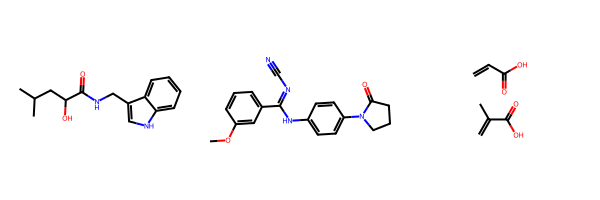

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

context_str = "XBr"


# def str_to_int(s):
#     return np.array([vocab[ch] for ch in tokenize_smiles(s)])
# def int_to_str(x):
#     return "".join([invocab[i] for i in x])

context = torch.unsqueeze(torch.tensor(t.str_to_int(context_str)), dim=0).to(device)
generated_str = t.int_to_str(model.generate(context, max_new_tokens=200)[0].tolist())

def split_molecules(smiles_string: str, separator: str = "X") -> list:
    molecules = [mol for mol in smiles_string.split(separator) if mol.strip()]
    return molecules

molecule_list = split_molecules(generated_str)[1:-1]
print(molecule_list)


def is_valid_smiles(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    return mol is not None

def mol_list(smiles_list):
    mol_list = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            mol_list.append(mol)
    return mol_list

mol_list = mol_list(molecule_list)
grid_img = Draw.MolsToGridImage(mol_list)
# grid_img.save("molecules_grid.png")
grid_img

# Now using Transformers to generate the molecules

# preprocessing.py

In [ ]:
# model.py

import torch


def custom_one_hot_embedding(X, embedding_dim):
    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=torch.long)
    one_hot = torch.nn.functional.one_hot(X, num_classes=embedding_dim).float()

    return one_hot

class Head(torch.nn.Module):
    #self attention head

    def __init__(self, head_size, embedding_dim, block_size):
        super().__init__()
        self.key = torch.nn.Linear(embedding_dim, head_size, bias=False)
        self.query = torch.nn.Linear(embedding_dim, head_size, bias=False)
        self.value = torch.nn.Linear(embedding_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei= q @ k.transpose(-2,-1) * C**(-0.5)
        wei = wei.masked_fill(self.tril[:T, :T]==0, float('-inf'))
        wei = torch.nn.functional.softmax(wei, dim=-1)

        v = self.value(x)
        out = wei @ v
        return out


class MultiHeadAttention(torch.nn.Module):
    """Multiple heads of self-attention mechanism"""

    def __init__(self, n_head, head_size, embedding_dim, block_size):
        super().__init__()
        self.heads = torch.nn.ModuleList([Head(head_size, embedding_dim, block_size) for _ in range(n_head)])
        self.proj = torch.nn.Linear(embedding_dim, embedding_dim)
    def forward(self, x):
        out =  torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out


class FeedForward(torch.nn.Module):

    def __init__(self, embedding_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(embedding_dim, 4 * embedding_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dim, embedding_dim),
        )

    def forward(self, x):
        return self.net(x)

class Block(torch.nn.Module):
    def __init__(self, n_head, embedding_dim, block_size):
        super().__init__()
        head_size = embedding_dim // n_head
        self.sa = MultiHeadAttention(n_head, head_size, embedding_dim, block_size)
        self.ffwd = FeedForward(embedding_dim)

    def forward(self, x):
        x = x + self.sa(x)
        x = x + self.ffwd(x)
        return x



class Transformer(torch.nn.Module):
    def __init__(self, embedding_dim, block_size, vocab_size, device):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.embedding_dim = embedding_dim
        self.n_head = 4

        self.device = device

        self.token_embedding_table = torch.nn.Embedding(self.vocab_size, self.embedding_dim)
        self.position_embedding_table = torch.nn.Embedding(self.block_size, self.embedding_dim)

        self.blocks = torch.nn.Sequential(
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
            Block(self.n_head, self.embedding_dim, self.block_size),
        )
        self.lm_head = torch.nn.Linear(embedding_dim, vocab_size)


    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_embd = self.token_embedding_table(idx)
        # tok_embd = custom_one_hot_embedding(idx, self.vocab_size)
        pos_embd = self.position_embedding_table(torch.arange(T, device=self.device))
        x = tok_embd + pos_embd
        x = self.blocks(x)
        logits = self.lm_head(x)

        if targets==None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = torch.nn.functional.cross_entropy(logits.float(), targets)

        return logits, loss

    def load_model(self, path):
        self.load_state_dict(torch.load(path))
        self.eval()

    def save_model(self, path):
        print("\nSaving model...")
        torch.save(self.state_dict(), path)# trainer.py
        print("\nModel saved...")

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = torch.nn.functional.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
t = Tokenizer()
train_seq, val_seq = t.create_train_val("smiles_clean.csv", train_size=0.8)

The size of vocab :  37

Preprocessing data...
Data loaded.
Total tokens: 66789284
Preprocessing done.
Training tokens: 53431427
Val tokens: 13357857


In [ ]:
VOCAB_SIZE = len(t.vocab)
print(f"Vocab size: {VOCAB_SIZE}")
BATCH_SIZE = 128
BLOCK_SIZE = 50
MAX_ITERS = 20000
EVAL_INTERVAL = 500
LR = 1e-3
EVAL_ITERS = 200
N_EMBD = 36

Vocab size: 37


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# model = Transformer(N_EMBD, BLOCK_SIZE, VOCAB_SIZE, device).to(device)

# load the model parameters
# model.load_state_dict(torch.load('model_transformer.pth', map_location=torch.device('cpu')))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params}")


Using device: cuda
Total parameters : 130645


In [ ]:
def get_batch(split):
  data = train_seq if split == "train" else val_seq
  ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
  x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
  y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
  x, y = x.to(device), y.to(device)
  return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X,Y = get_batch(split)
            logits, loss = model(X,Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


def train():

  for iter in range(MAX_ITERS):

      if iter % EVAL_INTERVAL == 0:
          losses = estimate_loss()
          print(f"step {iter}: train loss {losses["train"]:.4f}, val loss: {losses["val"]:.4f}")

      xb,yb = get_batch("train")
      logits, loss = model(xb,yb)
      optimizer.zero_grad(set_to_none=True)
      loss.backward()
      optimizer.step()


In [ ]:
train()

step 0: train loss 0.7601, val loss: 0.7601
step 500: train loss 0.7582, val loss: 0.7612
step 1000: train loss 0.7594, val loss: 0.7603
step 1500: train loss 0.7596, val loss: 0.7624
step 2000: train loss 0.7604, val loss: 0.7592
step 2500: train loss 0.7606, val loss: 0.7617
step 3000: train loss 0.7571, val loss: 0.7607
step 3500: train loss 0.7613, val loss: 0.7594
step 4000: train loss 0.7578, val loss: 0.7600
step 4500: train loss 0.7589, val loss: 0.7583
step 5000: train loss 0.7595, val loss: 0.7596


KeyboardInterrupt: 

In [ ]:
model.load_model("model.pt")

In [ ]:
model.save_model("model_transformer.pth")


Saving model...

Model saved...


['O=C(NCCCCN(CC)CCC)CSC1=NC(=NC(=N1)C)C', 'C1=CC=C2C(=C1)C(=O)C(=C(O2)O)C(C3=NC=CC(=N3)Cl)CO', 'CC1=CC=C(O1)C(=O)OC2CCCCC2']


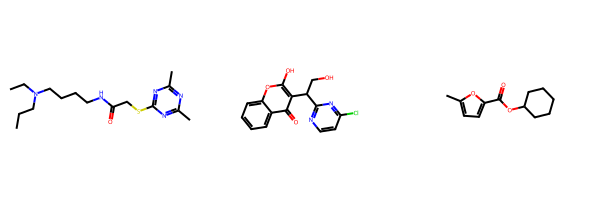

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

context_str = "X"


# def str_to_int(s):
#     return np.array([vocab[ch] for ch in tokenize_smiles(s)])
# def int_to_str(x):
#     return "".join([invocab[i] for i in x])

context = torch.unsqueeze(torch.tensor(t.str_to_int(context_str)), dim=0).to(device)
generated_str = t.int_to_str(model.generate(context, max_new_tokens=200)[0].tolist())

def split_molecules(smiles_string: str, separator: str = "X") -> list:
    molecules = [mol for mol in smiles_string.split(separator) if mol.strip()]
    return molecules

molecule_list = split_molecules(generated_str)[1:-1]
print(molecule_list)


def is_valid_smiles(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    return mol is not None

def mol_list(smiles_list):
    mol_list = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            mol_list.append(mol)
    return mol_list

mol_list = mol_list(molecule_list)
grid_img = Draw.MolsToGridImage(mol_list)
# grid_img.save("molecules_grid.png")
grid_img